In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

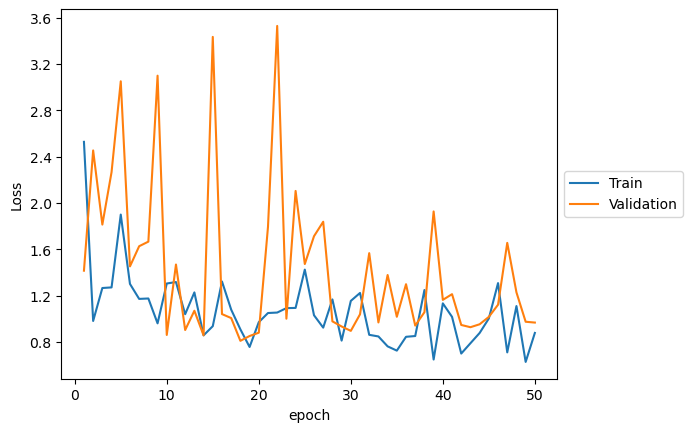

In [11]:
def extract_stats(path:str):
    train_losses = []
    val_losses = []
    train_accuracy = []
    val_accuracy = []

    with open(path, "r") as file:
        for line in file:
            if "Loss" in line:
                if "Test" in line:
                    pass
                else:
                    loss_line = line.split(",")[1].strip()
                    if "Train" in loss_line:
                        train_losses.append(loss_line[-6:])
                    else:
                        val_losses.append(loss_line[-6:])
                        
            if "Accuracy" in line:
                if "Test" in line:
                    pass
                else:
                    accuracy_line = line.split(":")[1].strip()
                    if "Train" in accuracy_line:
                        train_accuracy.append(accuracy_line[:6])
                    else:
                        val_accuracy.append(accuracy_line[:6])
                                            
        losses = pd.concat([
            pd.DataFrame({"Loss":train_losses, "type":"Train", "epoch":range(1, len(train_losses)+1)}),
            pd.DataFrame({"Loss": val_losses, "type":"Validation", "epoch":range(1, len(train_losses)+1)}),
        ]).reset_index()
        accuracy = pd.concat([
            pd.DataFrame({"Accuracy": train_accuracy, "type":"Train", "epoch":range(1, len(train_accuracy)+1)}),
            pd.DataFrame({"Accuracy": val_accuracy, "type":"Validation", "epoch":range(1, len(train_accuracy)+1)})
        ]).reset_index()
        
        losses = losses.assign(Loss = losses["Loss"].astype(float))
        accuracy = accuracy.assign(Accuracy = accuracy["Accuracy"].astype(float))
        
        data = pd.concat([losses, accuracy], axis=1, join="inner")
        return data.iloc[:, [0, 1, 2, 3, 5]]
        
    
def plot_stats(data, var:str="Loss"):
    fig, ax = plt.subplots()
    sns.lineplot(data, x="epoch", y=var, hue="type")
    plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10)) 
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    
    return fig
    
mha_model_output = "output_model_training_65941733.txt"
mean_model_output = "output_model_training_65941800.txt"

plot_stats(extract_stats(mean_model_output)).savefig("zzz.png", bbox_inches="tight", dpi=200)

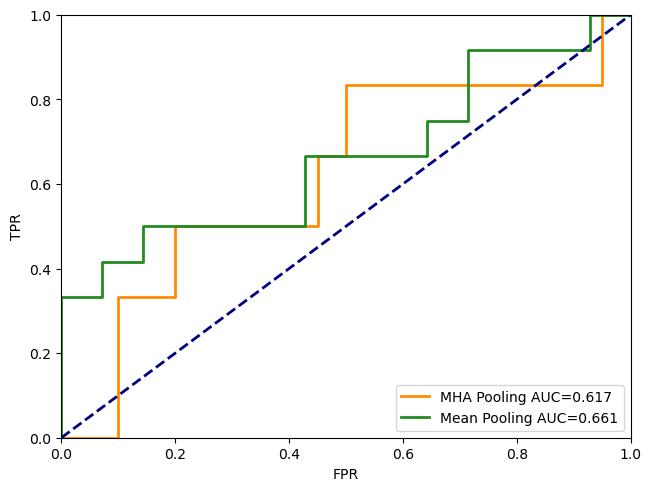

In [11]:
def plot_roc(fprs, tprs, aucs):
    fig, axs = plt.subplots(layout="constrained")
    colors = ["darkorange", "forestgreen"]
    names = ["MHA Pooling", "Mean Pooling"]
    i = 0
    for fpr, tpr, auc in zip(fprs, tprs, aucs):
        axs.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{names[i]} AUC={auc:.3}")
        i += 1
    
    axs.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    axs.set_xlim([0,1])
    axs.set_ylim([0,1])
    axs.set_xlabel("FPR")
    axs.set_ylabel("TPR")
    axs.legend(loc="lower right")
    
    return fig

mha_fpr = [0, 0.05, 0.1, 0.1, 0.2, 0.2, 0.45, 0.45, 0.5, 0.5, 0.95, 0.95, 1]
mha_tpr = [0, 0, 0, 0.33333333, 0.33333333, 0.5, 0.5, 0.66666667, 0.66666667, 0.83333333, 0.83333333, 1, 1]
mha_auc = 0.6166666666666667

mean_fpr = [0, 0, 0, 0.07142857, 0.07142857, 0.14285714, 0.14285714, 0.42857143, 0.42857143, 0.64285714, 0.64285714, 0.71428571, 0.71428571, 0.92857143, 0.92857143, 1]
mean_tpr = [0, 0.08333333, 0.33333333, 0.33333333, 0.41666667, 0.41666667, 0.5, 0.5, 0.66666667, 0.66666667, 0.75, 0.75, 0.91666667, 0.91666667, 1, 1]
mean_auc = 0.6607142857142857

fprs = [mha_fpr, mean_fpr]
tprs = [mha_tpr, mean_tpr]
aucs = [mha_auc, mean_auc]

plot_roc(fprs, tprs, aucs).savefig("zzz.png", dpi=200)